In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
%cd /content/gdrive/MyDrive/'Colab Notebooks'/DNA_Final1
!ls

Mounted at /content/gdrive
/content/gdrive/MyDrive/Colab Notebooks/DNA_Final1
 all_traj_DNAonly.npz	   Energies.ipynb    V3.ipynb
 checkpoints		   eval_input.xyz    V4.ipynb
 dna_mace_allfloat32.pt    logs		     V5.ipynb
 dna_mace_compiled.model   merged_data.npz   valid_indices_123.txt
 dna_mace_dataset.xyz	   results	    'Копие на V3.ipynb'
 dna_mace_fixed.pt	   topology.prmtop  'Копие на V5.ipynb'
 dna_mace.model		   V1.ipynb
 E0s.txt		   V2.ipynb


In [ ]:
!pip install netCDF4
!pip install parmed
!pip install openmm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 95.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 122.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for parmed: filename=ParmEd-4.3.0-cp312-cp312-linux_x86_64.whl size=19471507 sha256=828ce94cb761044724cb0a8a7bdfdb109eb62c9fe3ff000b65090f313e439d87
  Stored in directory: /root/.cache/pip/wheels/a3/c6/57/3ff4e09a91685738568d531ee739797913dd13b3553e202234
Successfully built parmed
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 112.7 MB/s eta 0:00:00


In [ ]:
import os
import re
import tqdm
import netCDF4
import numpy as np
import parmed as pmd
from tqdm import tqdm

import math
import pickle
import argparse
from sys import exit
from sklearn import datasets
import matplotlib.pyplot as plt

import openmm
from openmm import app, openmm
from openmm import unit, LangevinIntegrator
from openmm.app import AmberPrmtopFile, Simulation

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
import torch.nn.functional as F
import torch.nn.functional as functional
from torch.utils.data import DataLoader, TensorDataset

torch.set_default_dtype(torch.float32)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
data = np.load("all_traj_DNAonly.npz")

coords = data["coords"]   # shape: (TOTAL_FRAMES, 1894, 3)
boxes  = data["boxes"]    # shape: (TOTAL_FRAMES, 3)

print("coords shape:", coords.shape)
print("boxes shape :", boxes.shape)

coords shape: (8050, 1894, 3)
boxes shape : (8050, 3)


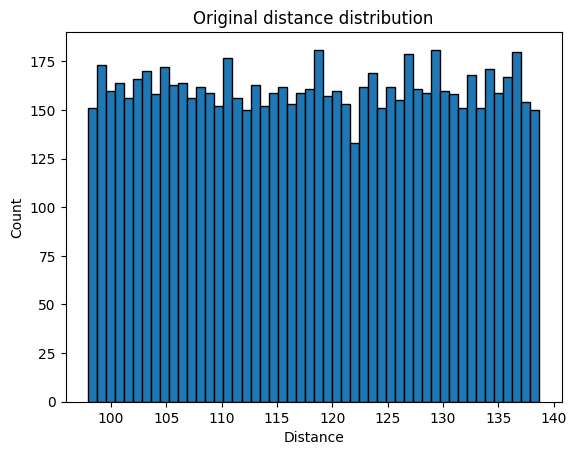

In [ ]:
p1, p2, p3, p4 = 30, 943, 946, 1871

def middlePoint(one, two):
    return (one + two) / 2.0

def dist(one, two):
    return math.sqrt(np.sum((one - two)**2))

def compute_distances(trajectories, p1, p2, p3, p4):
    distances = []
    for coords in trajectories:
        leftEnd  = middlePoint(coords[p1], coords[p4])
        rightEnd = middlePoint(coords[p2], coords[p3])
        distances.append(dist(leftEnd, rightEnd))
    return torch.tensor(distances, dtype=torch.float32).unsqueeze(1)

distances_orig = compute_distances(coords, p1, p2, p3, p4)

plt.hist(distances_orig.numpy(), bins=50, edgecolor='black')
plt.title("Original distance distribution")
plt.xlabel("Distance")
plt.ylabel("Count")
plt.show()

In [ ]:
from openmm.app import *
from openmm import *
from openmm.unit import *
import parmed as pmd
import numpy as np
from tqdm import tqdm
import openmm.unit as u

def compute_openmm_energy_forces(coords, boxes, prmtop, n_atoms=1894):

    # Load DNA-only topology
    structure = pmd.load_file(prmtop)[:n_atoms]

    # Build system with PME and periodic boundaries
    system = structure.createSystem(
        nonbondedMethod=PME,
        nonbondedCutoff=1.2*u.nanometer,
        constraints=None
    )

    topology = structure.topology

    integrator = VerletIntegrator(1.0 * u.femtoseconds)
    simulation = Simulation(topology, system, integrator)

    N = coords.shape[0]

    energies = np.zeros(N, dtype=np.float32)
    forces  = np.zeros((N, n_atoms, 3), dtype=np.float32)

    print("Computing OpenMM total energies + forces...")

    for i in tqdm(range(N)):
        xyz = coords[i] * angstrom
        simulation.context.setPositions(xyz)

        # Set PME periodic box
        a, b, c = boxes[i]
        simulation.context.setPeriodicBoxVectors(
            (a*angstrom, 0, 0),
            (0, b*angstrom, 0),
            (0, 0, c*angstrom)
        )

        state = simulation.context.getState(getEnergy=True, getForces=True)

        E = state.getPotentialEnergy().value_in_unit(kilocalories_per_mole)
        F = state.getForces(asNumpy=True).value_in_unit(kilocalories_per_mole/angstrom)

        energies[i] = E
        forces[i]   = F[:n_atoms]   # DNA-only

    # Convert to eV and eV/Å
    kcal_to_eV = 0.0433641
    energies *= kcal_to_eV
    forces   *= kcal_to_eV

    return energies, forces


In [ ]:
data = np.load("all_traj_DNAonly.npz")
coords = data["coords"]   # (N, 1894, 3)
boxes  = data["boxes"]    # (N, 3)

energies, forces = compute_openmm_energy_forces(
    coords, boxes,
    prmtop="topology.prmtop"
)

print("Energies:", energies.shape)
print("Forces:", forces.shape)


Computing OpenMM total energies + forces...


100%|██████████| 8050/8050 [00:05<00:00, 1521.92it/s]


Energies: (8050,)
Forces: (8050, 1894, 3)


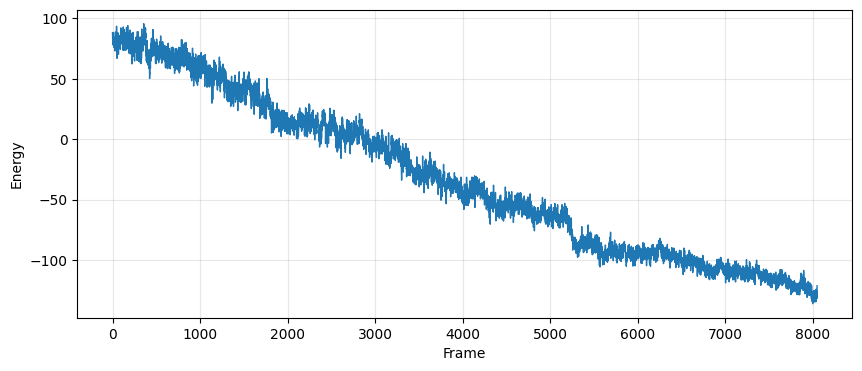

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(energies, lw=1)
plt.xlabel("Frame")
plt.ylabel("Energy")
plt.grid(alpha=0.3)
plt.show()


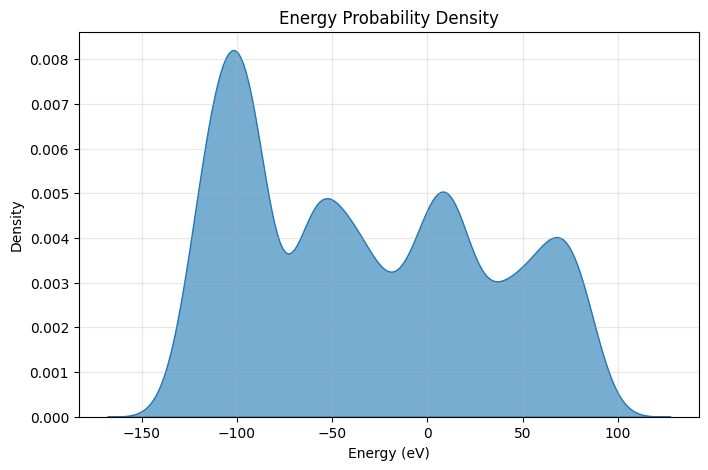

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(energies, fill=True, alpha=0.6)
plt.xlabel("Energy (eV)")
plt.ylabel("Density")
plt.title("Energy Probability Density")
plt.grid(alpha=0.3)
plt.show()


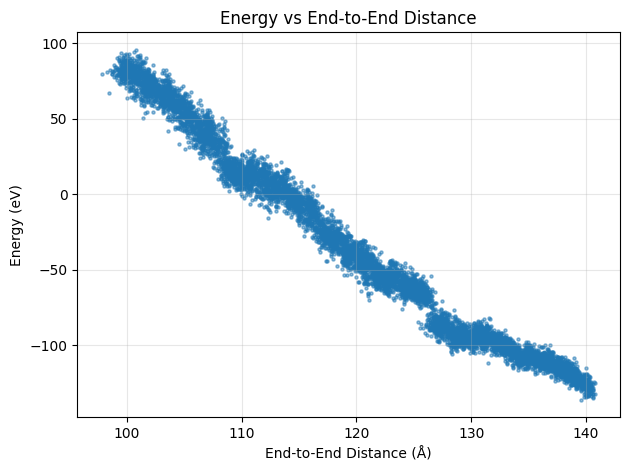

In [ ]:
p1, p4 = 30, 944  # or whatever your indices are

eed = np.linalg.norm(coords[:, p4] - coords[:, p1], axis=1)

plt.figure(figsize=(7,5))
plt.scatter(eed, energies, s=5, alpha=0.5)
plt.xlabel("End-to-End Distance (Å)")
plt.ylabel("Energy (eV)")
plt.title("Energy vs End-to-End Distance")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
def write_mace_xyz(filename, coords, forces, energies, boxes, prmtop, n_atoms=1894):
    """
    coords:   (N, n_atoms, 3)   in Å
    forces:   (N, n_atoms, 3)   in eV/Å
    energies: (N,)              in eV
    boxes:    (N, 3)            box lengths (a,b,c) in Å
    """


    structure = pmd.load_file(prmtop)[:n_atoms]
    atom_names = [atom.element_name for atom in structure.atoms]

    N = coords.shape[0]

    with open(filename, "w") as f:
        for i in range(N):
            xyz = coords[i]
            frc = forces[i]
            E   = energies[i]
            a, b, c = boxes[i]


            f.write(f"{n_atoms}\n")
            f.write(
                f'Lattice="{a} 0 0  0 {b} 0  0 0 {c}" '
                f'Properties=species:S:1:pos:R:3:REF_forces:R:3 '
                f'REF_energy={E}\n'
            )

            for name, (x, y, z), (fx, fy, fz) in zip(atom_names, xyz, frc):
                f.write(f"{name}  {x:.6f} {y:.6f} {z:.6f}  {fx:.6f} {fy:.6f} {fz:.6f}\n")

    print(f"Saved MACE-ready dataset to {filename}")


In [ ]:
coords = data["coords"]
boxes  = data["boxes"]
energies = energies
forces   = forces

write_mace_xyz(
    filename="dna_mace_dataset.xyz",
    coords=coords,
    forces=forces,
    energies=energies,
    boxes=boxes,
    prmtop="topology.prmtop",
    n_atoms=1894
)


Saved MACE-ready dataset to dna_mace_dataset.xyz


In [ ]:
!pip install mace-torch ase parmed

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 62.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.7/387.7 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 118.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.4/299.4 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 453.1/453.1 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 56.8 MB/s eta 0:00:00
  Created wheel for parmed: filename=ParmEd-4.3.0-cp312-cp312-linux_x86_64.whl size=19471504 sha256=0c32c81dd8403276afcde64965f1982fd9b479fba21e6a96cc5f60ed1c43ed91
  Stored in directory: /root/.cache/pip/wheels/a3/c6/57/3ff4e09a91685738568d531ee739797913dd13b3553e202234
  Created wheel for python-hostlist: filename=python_hostlist-2.3.0-py3-none-any.w

In [ ]:
!mace_run_train \
  --name="dna_mace" \
  --train_file="dna_mace_dataset.xyz" \
  --valid_fraction=0.1 \
  --model="MACE" \
  --E0s="average" \
  --r_max=6.0 \
  --num_interactions=2 \
  --num_channels=64 \
  --max_L=1 \
  --batch_size=4 \
  --valid_batch_size=4 \
  --max_num_epochs=3 \
  --energy_weight=1.0 \
  --forces_weight=100.0 \
  --default_dtype="float32" \
  --device="cuda"


/usr/local/lib/python3.12/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
2025-12-02 14:27:07.887 INFO: ===========VERIFYING SETTINGS===========
2025-12-02 14:27:07.889 INFO: MACE version: 0.3.14
2025-12-02 14:27:07.912 INFO: CUDA version: 12.6, CUDA device: 0
2025-12-02 14:27:08.122 INFO: ===========LOADING INPUT DATA===========
2025-12-02 14:27:08.123 INFO: Using heads: ['Default']
2025-12-02 14:27:08.123 INFO: Using the key specifications to parse data:
2025-12-02 14:27:08.123 INFO: Default: KeySpecification(info_keys={'energy': 'REF_energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'hea

In [ ]:
!ls -R checkpoints

checkpoints:
dna_mace_run-123_epoch-2.pt  dna_mace_run-123.model


In [ ]:
!ls

 all_traj_DNAonly.npz	     logs	       V4.ipynb
 checkpoints		     merged_data.npz   V5.ipynb
 dna_mace_compiled.model     results	       valid_indices_123.txt
 dna_mace_dataset_2000.xyz   topology.prmtop  'Копие на V3.ipynb'
 dna_mace_dataset.xyz	     V1.ipynb	      'Копие на V5.ipynb'
 dna_mace.model		     V2.ipynb
 Energies.ipynb		     V3.ipynb


In [ ]:
import numpy as np

data = np.load("all_traj_DNAonly.npz")

coords = data["coords"]
boxes  = data["boxes"]

print("coords shape:", coords.shape)
print("boxes shape :", boxes.shape)

coords shape: (8050, 1894, 3)
boxes shape : (8050, 3)


In [ ]:
import parmed as pmd

prmtop = "topology.prmtop"
n_atoms = coords.shape[1]

structure = pmd.load_file(prmtop)[:n_atoms]
species = np.array([atom.atomic_number for atom in structure.atoms], dtype=int)

print("species shape:", species.shape)
print("unique atomic numbers:", np.unique(species))


species shape: (1894,)
unique atomic numbers: [ 1  6  7  8 15]


In [ ]:
from mace.calculators import MACECalculator
from ase import Atoms

/usr/local/lib/python3.12/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [ ]:
import numpy as np
import parmed as pmd

data = np.load("all_traj_DNAonly.npz")
coords = data["coords"]
boxes  = data["boxes"]

N, n_atoms, _ = coords.shape
print("Frames:", N, "Atoms:", n_atoms)


structure = pmd.load_file("topology.prmtop")[:n_atoms]
species = np.array([atom.atomic_number for atom in structure.atoms], dtype=int)
print("Species example:", species[:10])


Frames: 8050 Atoms: 1894
Species example: [1 8 6 1 1 6 1 8 6 1]


In [ ]:
number_to_symbol = {
    1:  "H",
    6:  "C",
    7:  "N",
    8:  "O",
    15: "P",
}

symbols = [number_to_symbol[int(Z)] for Z in species]


In [ ]:
from mace.calculators import MACECalculator

mace_calc = MACECalculator(
    model_paths=["dna_mace_compiled.model"],
    device="cuda",
    default_dtype="float32",
)


/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/usr/local/lib/python3.12/dist-packages/torch/serialization.py:1493: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  warnings.warn(


Using head Default out of ['Default']


In [ ]:
from ase import Atoms
from tqdm import tqdm

energies_mace = []

for i in tqdm(range(N), desc="Evaluating MACE"):
    a, b, c = boxes[i]

    atoms = Atoms(
        symbols=symbols,
        positions=coords[i],
        cell=[a, b, c],
        pbc=[True, True, True],
    )
    atoms.calc = mace_calc

    E = atoms.get_potential_energy()
    energies_mace.append(E)

energies_mace = np.array(energies_mace)
print("Energies_mace shape:", energies_mace.shape)
print("First 5 energies (eV):", energies_mace[:5])


Evaluating MACE: 100%|██████████| 8050/8050 [16:38<00:00,  8.06it/s]

Energies_mace shape: (8050,)
First 5 energies (eV): [-49.81160736 -45.27981186 -49.39766312 -48.49118423 -52.27958298]


In [12]:
import matplotlib.pyplot as plt


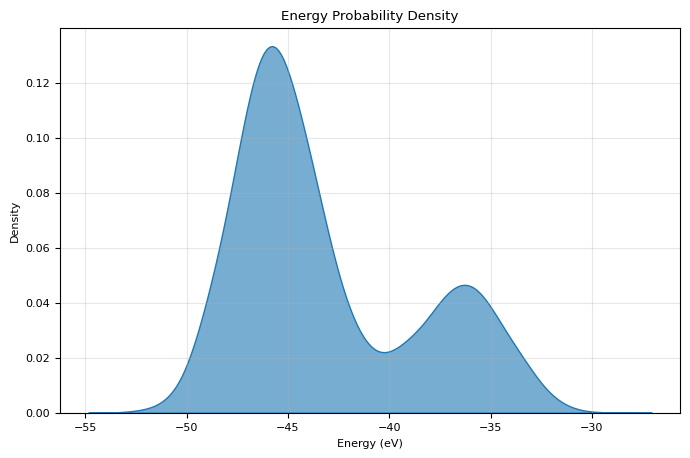

In [13]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(energies_mace, fill=True, alpha=0.6)
plt.xlabel("Energy (eV)")
plt.ylabel("Density")
plt.title("Energy Probability Density")
plt.grid(alpha=0.3)
plt.show()


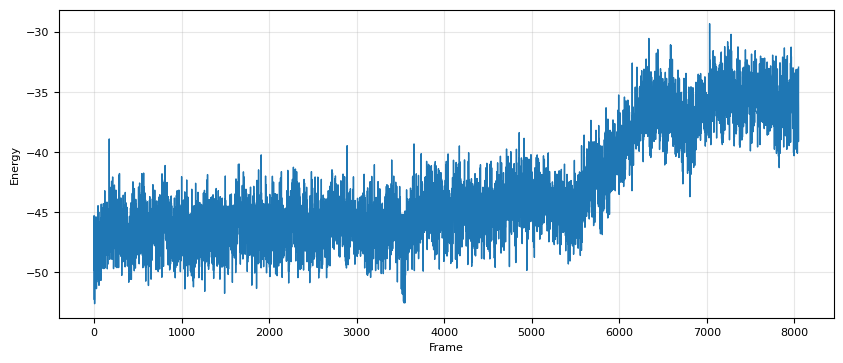

In [14]:
plt.figure(figsize=(10,4))
plt.plot(energies_mace, lw=1)
plt.xlabel("Frame")
plt.ylabel("Energy")
plt.grid(alpha=0.3)
plt.show()


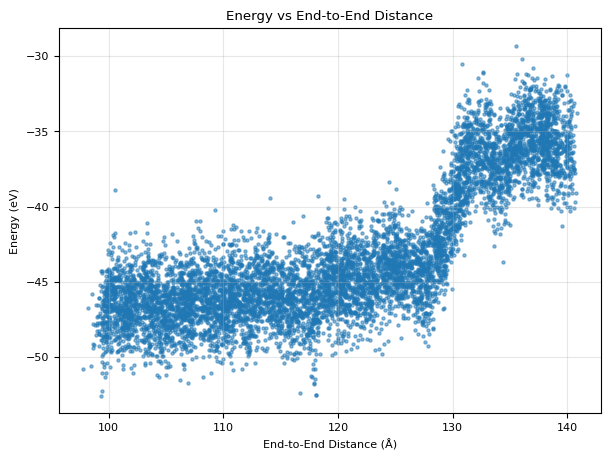

In [15]:
p1, p4 = 30, 944
eed = np.linalg.norm(coords[:, p4] - coords[:, p1], axis=1)

plt.figure(figsize=(7,5))
plt.scatter(eed, energies_mace, s=5, alpha=0.5)
plt.xlabel("End-to-End Distance (Å)")
plt.ylabel("Energy (eV)")
plt.title("Energy vs End-to-End Distance")
plt.grid(alpha=0.3)
plt.show()
